In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D
from tensorflow.keras import layers

Lectura de datos

In [2]:
import pandas as pd
datos = pd.read_excel("02.Generación Pearson CT-NET.xlsx")
datos["Generacion_prev_hour"] = datos["Generación"].shift(1)
datos = datos.dropna(how="any", axis= 0)
datos.index = pd.to_datetime(datos['Fecha'], format='%Y-%m-%d %H:%M:%s')
datos = datos.drop(columns='Fecha', axis=1)
datos.head(4)

,Generación,Índice UV,Temperatura,Humedad Relativa,Generacion_prev_hour
Fecha,,,,,
2022-09-01 01:00:00,0.0,0.0,19,82,0.0
2022-09-01 02:00:00,0.0,0.0,18,85,0.0
2022-09-01 03:00:00,0.0,0.0,18,87,0.0
2022-09-01 04:00:00,0.0,0.0,18,88,0.0


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18289 entries, 2022-09-01 01:00:00 to 2024-10-03 00:00:00
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Generación            18289 non-null  float64
 1   Índice UV             18289 non-null  float64
 2   Temperatura           18289 non-null  int64  
 3   Humedad Relativa      18289 non-null  int64  
 4   Generacion_prev_hour  18289 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 857.3 KB


In [4]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Generación,18289.0,9392.983969,11398.764291,0.0,0.0,533.0,21830.0,30000.0
Índice UV,18289.0,1.976613,3.181352,0.0,0.0,0.0,3.0,14.0
Temperatura,18289.0,19.456723,6.636719,0.0,15.0,19.0,24.0,39.0
Humedad Relativa,18289.0,58.878233,26.112575,3.0,37.0,62.0,83.0,100.0
Generacion_prev_hour,18289.0,9392.983969,11398.764291,0.0,0.0,533.0,21830.0,30000.0


In [5]:
def transform_data(data_to_transform):
    scaler = MinMaxScaler()
    scaler = scaler.fit(data_to_transform)
    trans_data = scaler.transform(data_to_transform)
    return trans_data

def to_supervised(train, n_input, n_out=12):
    data = train.reshape((train.shape[0]*train.shape[1], train.shape[2]))
    X, y = [], []
    in_start = 0
    for _ in range(len(data)):
        in_end = in_start + n_input
        out_end = in_end + n_out
        if out_end <= len(data):
            X.append(data[in_start:in_end, :])
            y.append(data[in_end:out_end, 0])
        in_start += 1
    return np.array(X), np.array(y)

def split_dataset(data):
    train = np.array(np.split(data, len(data)/12))
    return train

Dividimos 50-50

In [6]:
train = 9144
datos_train = datos[:train]
datos_test = datos[train:]
datos_train.shape

(9144, 5)

In [7]:
training_df = transform_data(datos_train)
training_df.shape

(9144, 5)

In [8]:
training_df = split_dataset(training_df)
training_df

array([[[0.        , 0.        , 0.5       , 0.81052632, 0.        ],
        [0.        , 0.        , 0.47368421, 0.84210526, 0.        ],
        [0.        , 0.        , 0.47368421, 0.86315789, 0.        ],
        ...,
        [0.31443698, 0.14285714, 0.5       , 0.92631579, 0.25735274],
        [0.73963825, 0.14285714, 0.52631579, 0.77894737, 0.31443698],
        [0.97323289, 0.42857143, 0.57894737, 0.62105263, 0.73963825]],

       [[0.84928238, 0.78571429, 0.60526316, 0.48421053, 0.97323289],
        [0.96858619, 0.85714286, 0.65789474, 0.37894737, 0.84928238],
        [1.        , 0.78571429, 0.68421053, 0.31578947, 0.96858619],
        ...,
        [0.        , 0.        , 0.55263158, 0.58947368, 0.01273959],
        [0.        , 0.        , 0.52631579, 0.66315789, 0.        ],
        [0.        , 0.        , 0.5       , 0.74736842, 0.        ]],

       [[0.        , 0.        , 0.47368421, 0.8       , 0.        ],
        [0.        , 0.        , 0.47368421, 0.83157895, 0. 

In [9]:
training_df.shape

(762, 12, 5)

In [10]:
Xtrain, Ytrain = to_supervised(training_df, 12)

In [11]:
print('shape of Training_input:', Xtrain.shape)
print('shape of Training_output:', Ytrain.shape)

shape of Training_input: (9121, 12, 5)
shape of Training_output: (9121, 12)


In [12]:
# Training Parameters
MAX_EPOCHS = 200

In [13]:
def compile_and_fit(model, xtrain=Xtrain, ytrain=Ytrain):
    model.compile(loss=[tf.keras.losses.MeanSquaredError()],
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError(), tf.keras.metrics.MeanAbsoluteError()])
    
    history = model.fit(xtrain, ytrain, epochs=MAX_EPOCHS,
                        batch_size=512, validation_split=0.3, verbose=1)
    return history

def Loss(train_loss, valid_loss):
    plt.plot(train_loss)
    plt.plot(valid_loss)
    plt.rcParams["figure.figsize"] = (15, 3)
    plt.title('Model Losses')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train Loss', 'Validation Loss'], loc='upper left')
    plt.savefig('out/loss_plot.png')
    plt.show()

def errors(Train_RMSE, Valid_RMSE, train_MAPE, Valid_MAPE):
    plt.plot(Train_RMSE)
    plt.plot(Valid_RMSE)
    plt.plot(train_MAPE)
    plt.plot(Valid_MAPE)
    plt.title('Model Errors')
    plt.ylabel('Error')
    plt.xlabel('Epoch')
    plt.legend(['Train RMSE', 'Validation RMSE', 'Train MAPE', 'Validation MAPE'], loc='upper left')
    plt.rcParams["figure.figsize"] = (15, 3)
    plt.savefig('out/errors_plot.png')
    plt.show()

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization()(inputs)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=128, kernel_size=2, activation="relu", padding="same")(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(norm_x, norm_x)
    res = x + inputs
    norm_x = layers.LayerNormalization()(res)
    return norm_x

def build_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    
    for _ in range(num_transformer_blocks):
        enc_out = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(enc_out, enc_out)
    res = x + enc_out
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    x = layers.Dense(832, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(12)(x)
    
    return tf.keras.Model(inputs, outputs)

In [14]:
input_shape = (12, 5)
CTNET = build_model(input_shape, head_size=4, num_heads=3, ff_dim=32, num_transformer_blocks=3, mlp_units=[256], mlp_dropout=0.3, dropout=0.2)

In [15]:
CTNET.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 5)     │         10 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 12, 32)    │        192 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 12, 128)   │      8,320 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 12, 5)     │        645 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 12, 5)     │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 5)     │         10 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 5)     │        281 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 12, 5)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 5)     │         10 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 5)     │        281 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 12, 5)     │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 5)     │         10 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 832)       │     10,816 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    106,624 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 12)        │        780 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 136,235 (532.17 KB)

 Trainable params: 136,235 (532.17 KB)

 Non-trainable params: 0 (0.00 B)

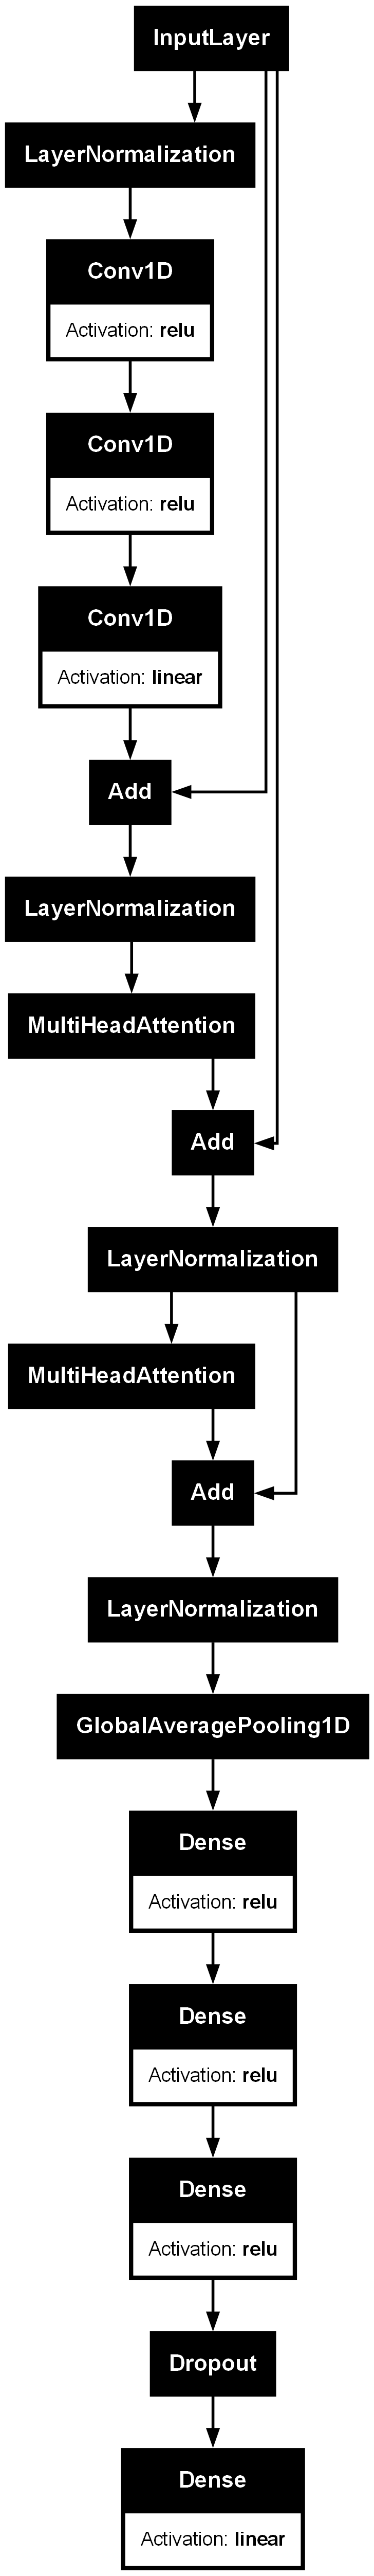

In [ ]:
import pydot
from tensorflow.keras.utils import plot_model
plot_model(CTNET, show_layer_activations=True)

In [16]:
history = compile_and_fit(CTNET)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 0.2119 - mean_absolute_error: 0.2800 - mean_absolute_percentage_error: 1273116.0000 - root_mean_squared_error: 0.4603 - val_loss: 0.3216 - val_mean_absolute_error: 0.3920 - val_mean_absolute_percentage_error: 5108462.0000 - val_root_mean_squared_error: 0.5671
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.2068 - mean_absolute_error: 0.2822 - mean_absolute_percentage_error: 7560660.0000 - root_mean_squared_error: 0.4547 - val_loss: 0.3085 - val_mean_absolute_error: 0.3907 - val_mean_absolute_percentage_error: 12552306.0000 - val_root_mean_squared_error: 0.5554
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1943 - mean_absolute_error: 0.2804 - mean_absolute_percentage_error: 16912374.0000 - root_mean_squared_error: 0.4408 - val_loss: 0.2900 - val_mean_absolute_error: 0.3896 - val_mean_absolute_percentage_error: 23873194.0000 - val_root_mean_squared_error: 0.5385
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━

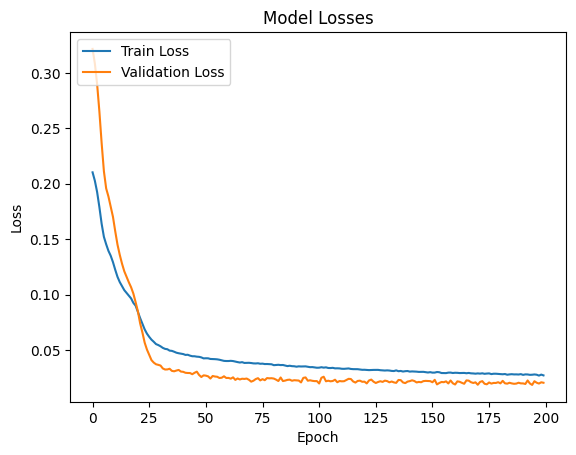

In [17]:
Loss(history.history['loss'], history.history['val_loss'])

In [18]:
CTNET.save('out/CTNET.h5')

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt
def evaluate_forecasts(actual, predicted):
    scores_MSE, scores_RMSE, scores_MAE, scores_MBE, scores_MAPE, scores_r2 = [], [], [], [], [], []
    for i in range(actual.shape[1]):
        MSE = mean_squared_error(actual[:, i], predicted[:, i])
        MAE = mean_absolute_error(actual[:, i], predicted[:, i])
        MAPE = mean_absolute_percentage_error(actual[:, i], predicted[:, i])
        MBE = np.mean(predicted[:, i] - actual[:, i])
        RMSE = sqrt(MSE)
        R2 = r2_score(actual[:, i], predicted[:, i])
        scores_MSE.append(MSE)
        scores_RMSE.append(RMSE)
        scores_MAE.append(MAE)
        scores_MBE.append(MBE)
        scores_MAPE.append(MAPE)
        scores_r2.append(R2)

    s_rmse, s_MSE, s_MAE, s_MAPE, s_MBE, s_R2 = 0, 0, 0, 0, 0, 0
    for row in range(actual.shape[0]):
        for col in range(actual.shape[1]):
            s_rmse += (actual[row, col] - predicted[row, col])**2
            s_MSE += (actual[row, col] - predicted[row, col])**2
            s_MAE += np.absolute(actual[row, col] - predicted[row, col])
            epsilon = np.finfo(np.float64).eps
            s_MAPE += (np.abs(actual[row, col] - predicted[row, col]) / np.maximum(np.abs(actual[row, col]), epsilon))
            s_MBE += (predicted[row, col] - actual[row, col])
            s_R2 += (predicted[row, col] - actual[row, col])

    score_RMSE = sqrt(s_rmse / (actual.shape[0] * actual.shape[1]))
    score_MSE = (s_MSE / (actual.shape[0] * actual.shape[1]))
    score_MAE = (s_MAE / (actual.shape[0] * actual.shape[1]))
    score_MAPE = (s_MAPE / (actual.shape[0] * actual.shape[1]))
    score_MBE = (s_MBE / (actual.shape[0] * actual.shape[1]))
    score_R2 = (s_R2 / (actual.shape[0] * actual.shape[1]))

    print('\nScore_RMSE:\n', score_RMSE)
    print('\nScore_MSE:\n', score_MSE)
    print('\nScore_MAE:\n', score_MAE)
    print('\nScore_MAPE:\n', score_MAPE)
    print('\nScore_MBE:\n', score_MBE)
    print('\nScore_R2:\n', score_R2)

    score_df = pd.DataFrame({'RMSE': [score_RMSE],
                             'MSE': [score_MSE],
                             'MAE': [score_MAE],
                             'MAPE': [score_MAPE],
                             'MBE': [score_MBE],
                             'R2': [score_R2]})

    score_df.to_csv('out/error_scores.csv', index=False)

In [20]:
datos_test.shape

(9145, 5)

In [21]:
testing_df = transform_data(datos_test[:-1])
testing_df = split_dataset(testing_df)

Xtest, Ytest = to_supervised(testing_df, 12)

In [22]:
print('shape of Training_input:', Xtest.shape)
print('shape of Training_output:', Ytest.shape)

shape of Training_input: (9121, 12, 5)
shape of Training_output: (9121, 12)


In [23]:
CTNET_predictions = CTNET.predict(Xtest)

286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [24]:
evaluate_forecasts(Ytest, CTNET_predictions)


Score_RMSE:
 0.16317500536785368

Score_MSE:
 0.026626082376799077

Score_MAE:
 0.09720818009071498

Score_MAPE:
 50992029960834.56

Score_MBE:
 -0.0203904986688107

Score_R2:
 -0.0203904986688107


In [25]:
Ytest_orig = Ytest.flatten()
CTNET_predictions_orig = CTNET_predictions.flatten()

In [26]:
def inverse_minmax_scaler(data_scaled, min_value=0, max_value=30000):
    return data_scaled * (max_value - min_value) + min_value

# Ejemplo de uso:
Ytest_orig = inverse_minmax_scaler(Ytest_orig)  # Si ya está en escala [0,1]
CTNET_predictions_orig = inverse_minmax_scaler(CTNET_predictions_orig)
CTNET_predictions_orig = np.clip(CTNET_predictions_orig, 0, 30000)

In [27]:
print(f"MAE: {mean_absolute_error(Ytest_orig, CTNET_predictions_orig):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Ytest_orig, CTNET_predictions_orig)):.4f}")
print(f"R²: {r2_score(Ytest_orig, CTNET_predictions_orig):.4f}")

MAE: 2862.0457
RMSE: 4891.7867
R²: 0.8080


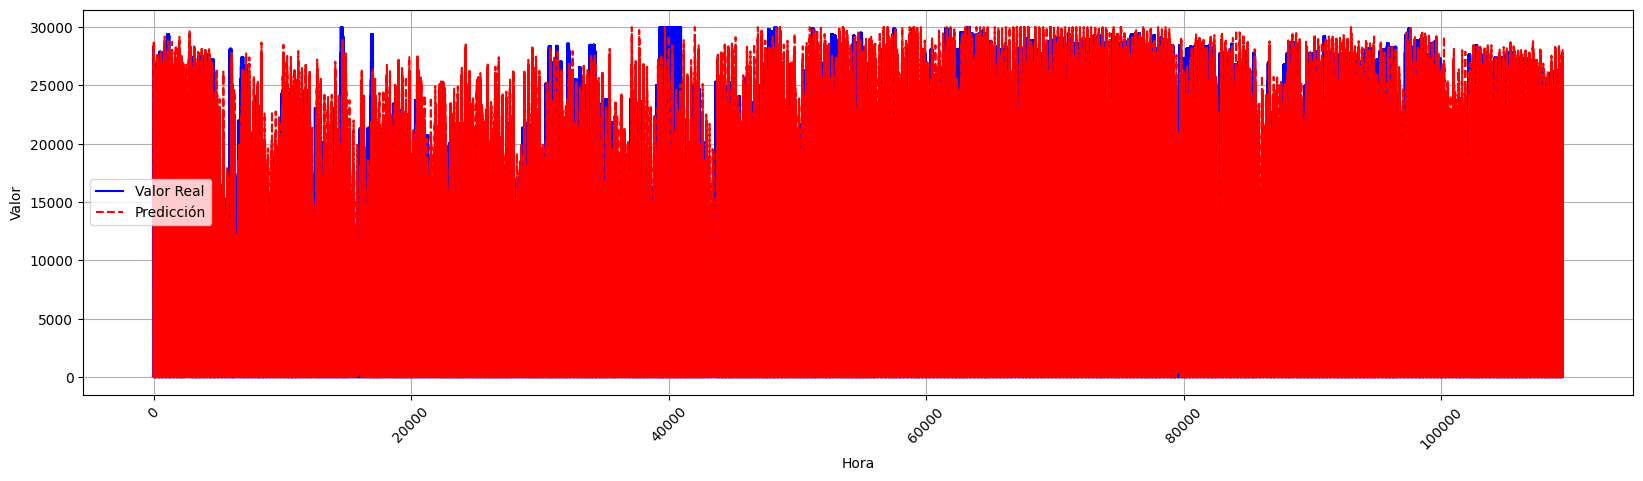

In [28]:
plt.figure(figsize=(20, 5))
plt.plot(Ytest_orig, label='Valor Real', color='blue')
plt.plot(CTNET_predictions_orig, label='Predicción', color='red', linestyle='dashed')
plt.xlabel("Hora")
plt.ylabel("Valor")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

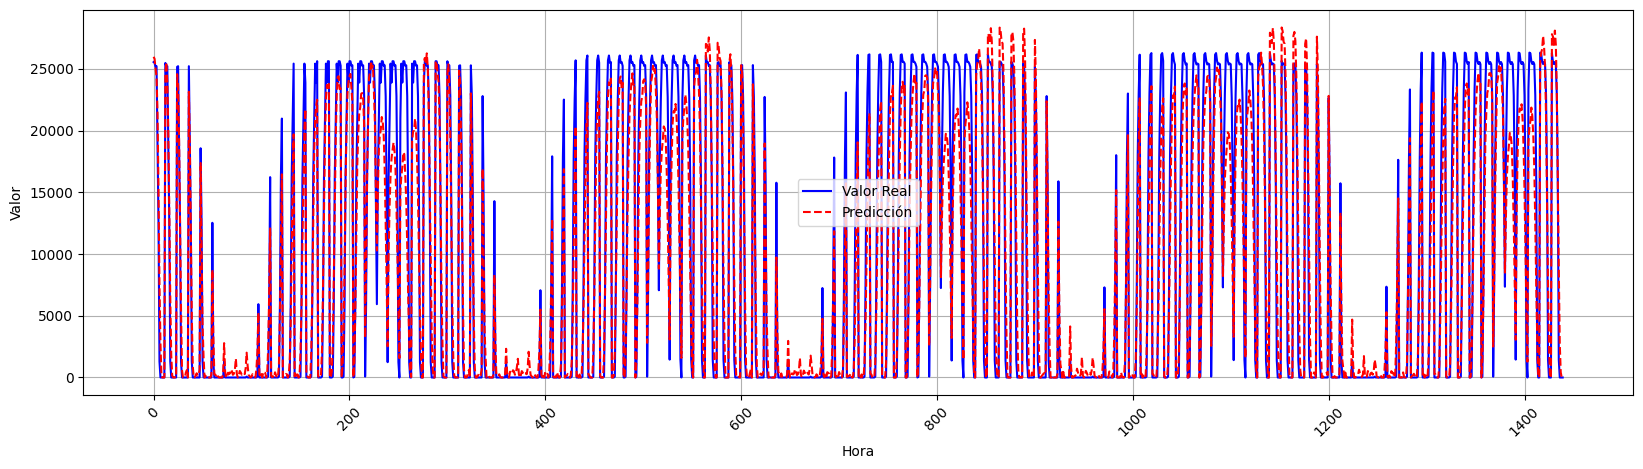

In [29]:
plt.figure(figsize=(20, 5))
plt.plot(Ytest_orig[-(24*60):], label='Valor Real', color='blue')
plt.plot(CTNET_predictions_orig[-(24*60):], label='Predicción', color='red', linestyle='dashed')
plt.xlabel("Hora")
plt.ylabel("Valor")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

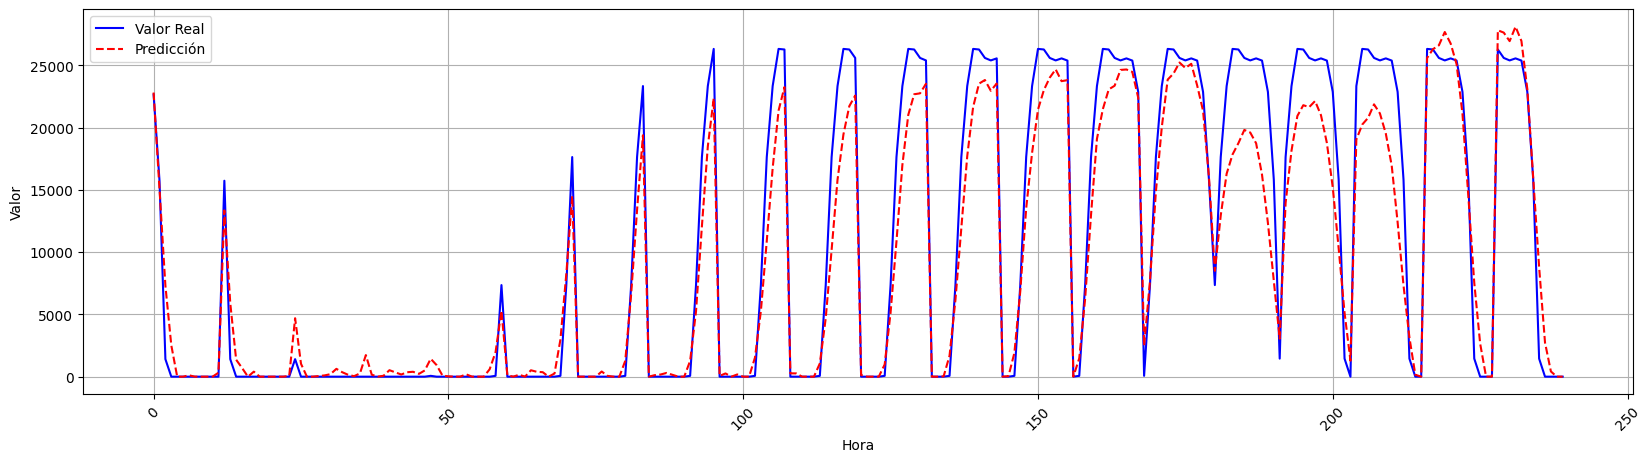

In [30]:
plt.figure(figsize=(20, 5))
plt.plot(Ytest_orig[-(24*10):], label='Valor Real', color='blue')
plt.plot(CTNET_predictions_orig[-(24*10):], label='Predicción', color='red', linestyle='dashed')
plt.xlabel("Hora")
plt.ylabel("Valor")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

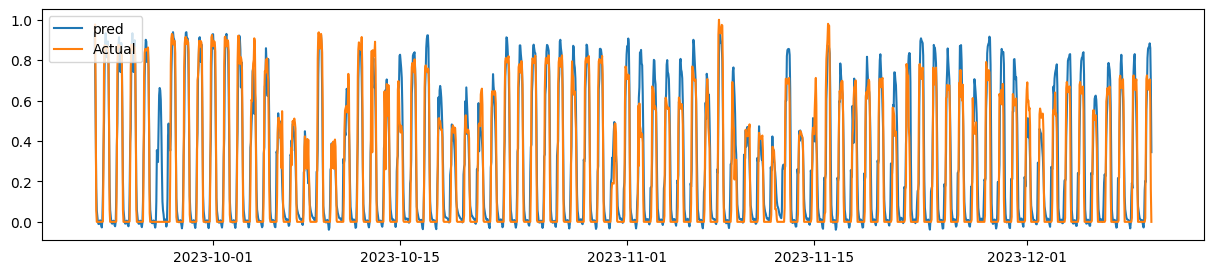

In [31]:
st_range = 100
end = 2000
plt.plot(datos_test.index[st_range:end], CTNET_predictions[st_range:end, 0], label='pred')
plt.plot(datos_test.index[st_range:end], Ytest[st_range:end, 0], label='Actual')
plt.legend(loc='upper left')
plt.savefig('out/prediction_plot.png')